In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv(r'D:\Internship-Project\Dataset\cinnamon\balanced_cinnamon_quality_dataset.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sample_ID               60 non-null     object 
 1   Moisture (%)            60 non-null     float64
 2   Ash (%)                 60 non-null     float64
 3   Volatile_Oil (%)        60 non-null     float64
 4   Acid_Insoluble_Ash (%)  60 non-null     float64
 5   Chromium (mg/kg)        60 non-null     float64
 6   Coumarin (mg/kg)        60 non-null     float64
 7   Quality_Label           60 non-null     object 
dtypes: float64(6), object(2)
memory usage: 3.9+ KB


In [3]:
print(df.head())

  Sample_ID  Moisture (%)  Ash (%)  Volatile_Oil (%)  Acid_Insoluble_Ash (%)  \
0      H001         10.56     5.93              1.24                    0.28   
1      H002         11.43     5.60              1.35                    0.25   
2      H003         11.10     5.70              1.21                    0.37   
3      H004         10.90     5.76              1.47                    0.27   
4      H005         10.23     5.82              1.28                    0.26   

   Chromium (mg/kg)  Coumarin (mg/kg) Quality_Label  
0            0.0019            0.0021          High  
1            0.0016            0.0039          High  
2            0.0013            0.0029          High  
3            0.0011            0.0035          High  
4            0.0013            0.0047          High  


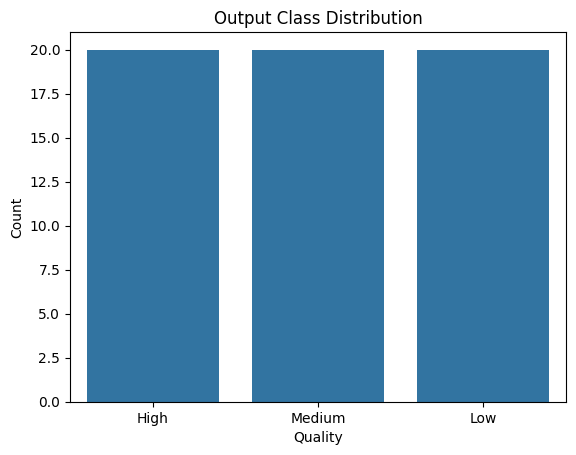

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target_column = "Quality_Label"  

plt.figure()
sns.countplot(x=df[target_column])

plt.title("Output Class Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")

plt.show()

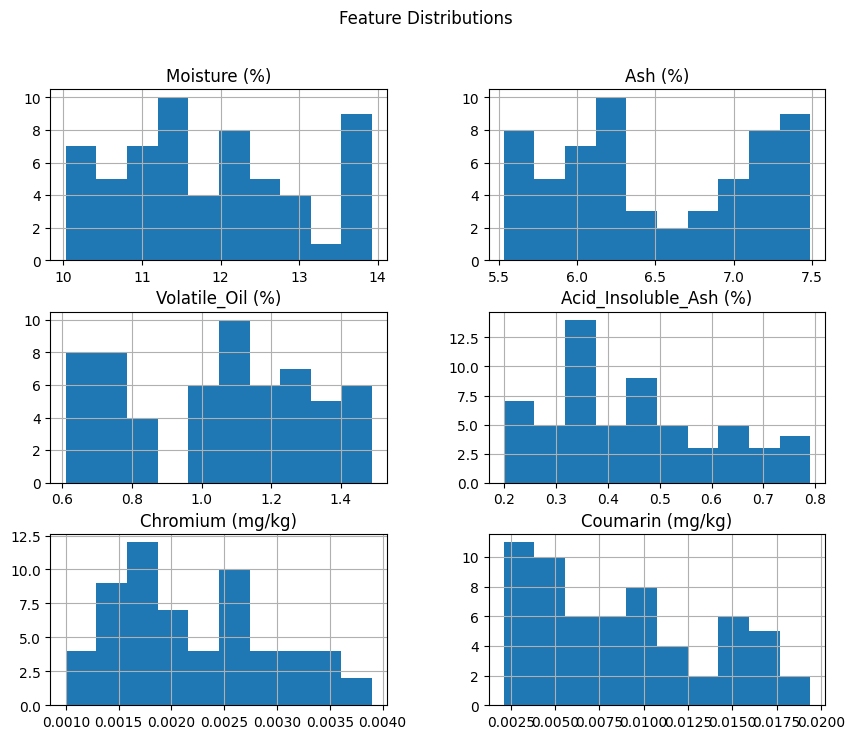

In [5]:
df.hist(figsize=(10, 8))
plt.suptitle("Feature Distributions")
plt.show()

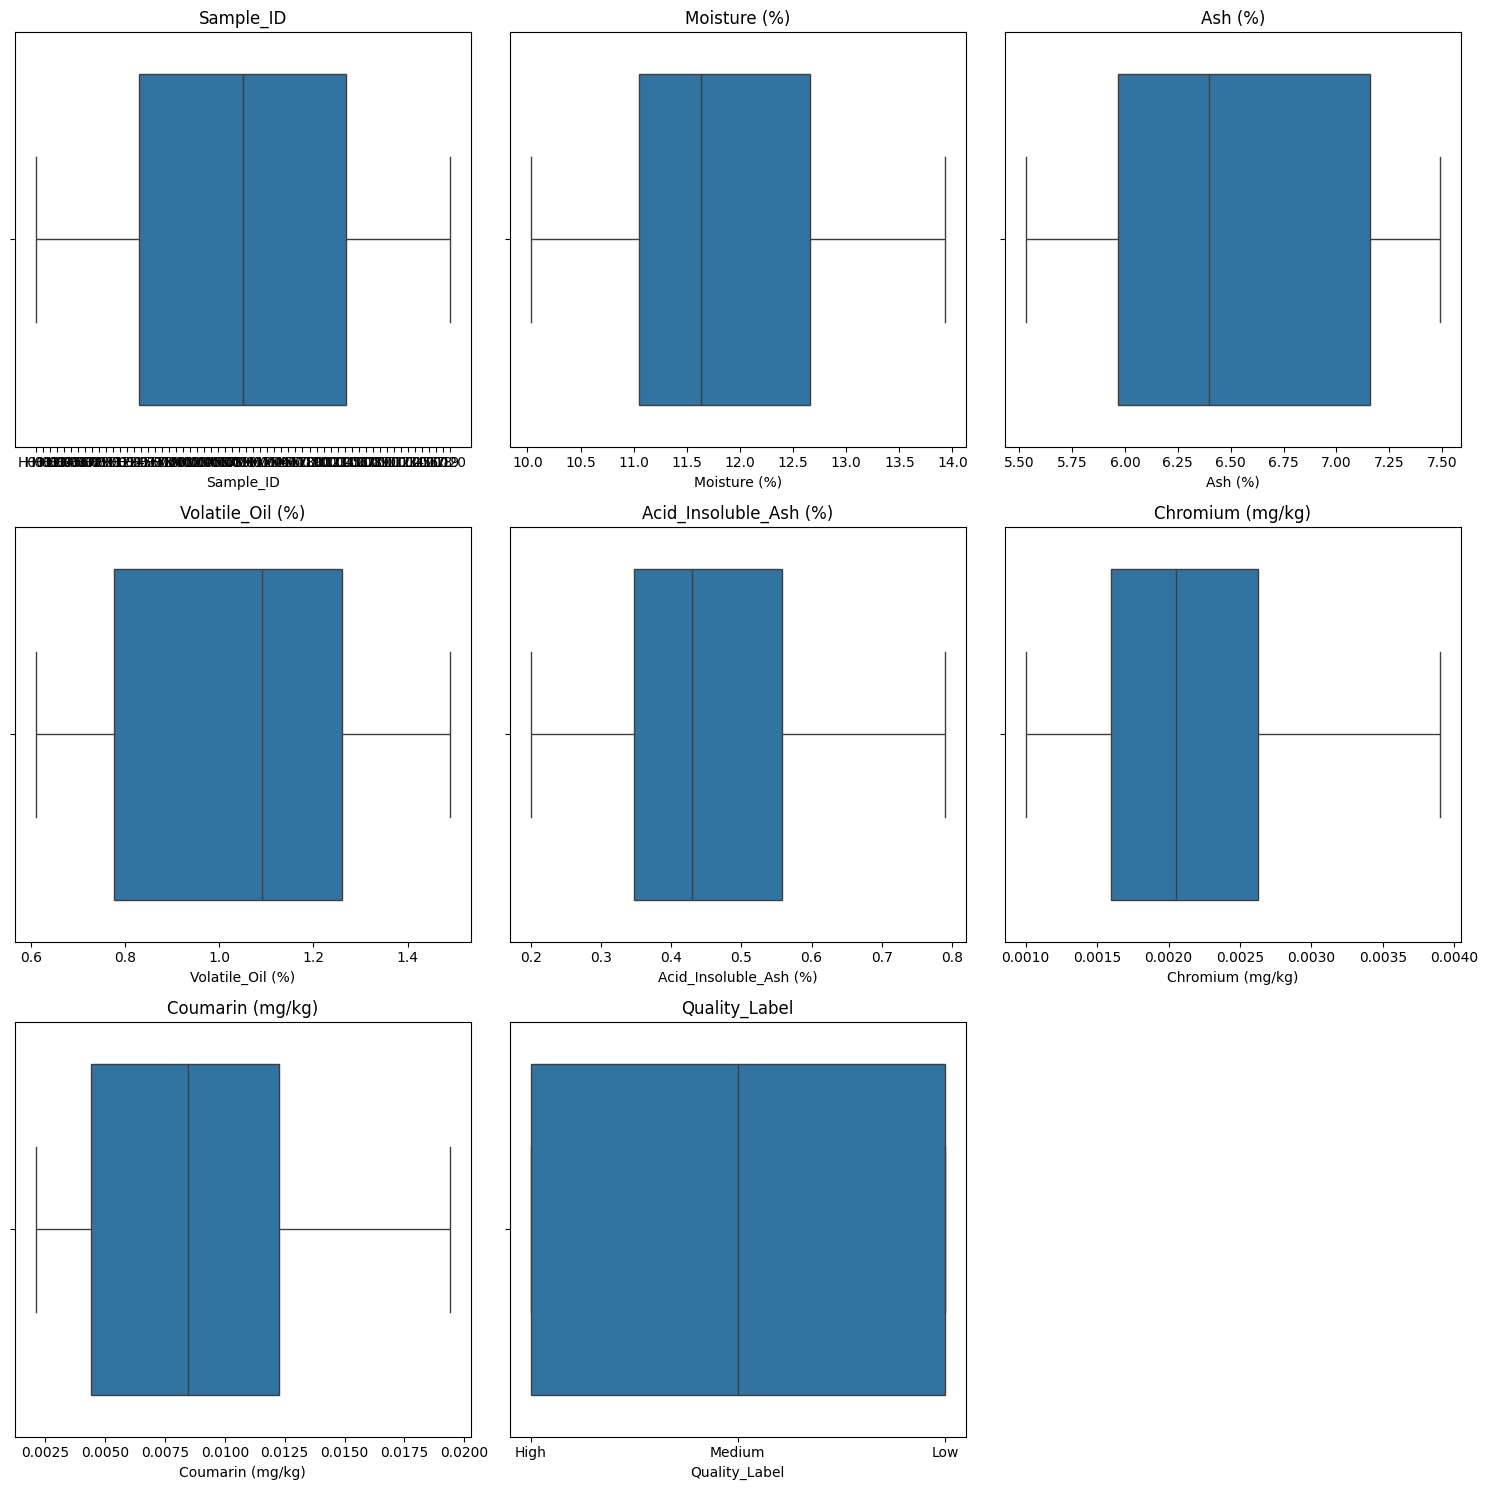

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Number of columns
num_cols = len(df.columns)

# Grid size (adjust automatically)
cols = 3   # number of plots per row
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(df.columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [8]:
target_column = "Quality_Label"   

X = df.drop(columns=[target_column])
y = df[target_column]

In [9]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(kernel='rbf'),
    "Logistic Regression": LogisticRegression()
}

In [12]:
results = {}

In [13]:
from sklearn.metrics import accuracy_score, classification_report
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"Accuracy: {acc}")
    print(classification_report(y_test, y_pred))



🔹 Training Decision Tree...
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         2

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


🔹 Training Random Forest...
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         2

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


🔹 Training SVM...
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
          

In [14]:
print("\n📊 Model Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc}")

best_model = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model}")


📊 Model Comparison:
Decision Tree: 1.0
Random Forest: 1.0
SVM: 1.0
Logistic Regression: 1.0

🏆 Best Model: Decision Tree


In [15]:
print("\n📊 Model Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc * 100:.2f}%")

best_model = max(results, key=results.get)

print(f"\n🏆 Best Model: {best_model} ({results[best_model] * 100:.2f}%)")


📊 Model Comparison:
Decision Tree: 100.00%
Random Forest: 100.00%
SVM: 100.00%
Logistic Regression: 100.00%

🏆 Best Model: Decision Tree (100.00%)


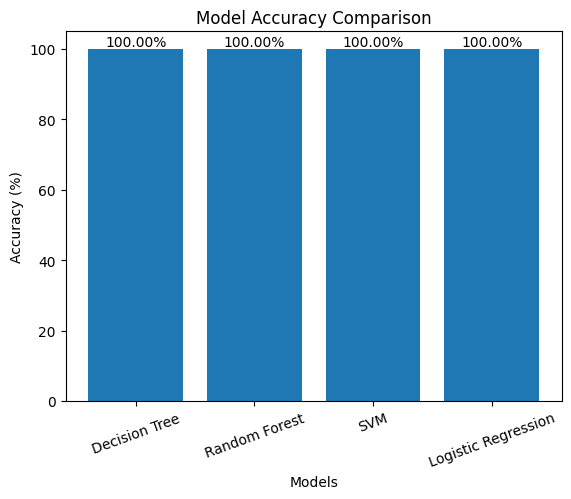

In [16]:
import matplotlib.pyplot as plt

# Convert to percentage
names = list(results.keys())
values = [acc * 100 for acc in results.values()]

plt.figure()

bars = plt.bar(names, values)

# Add percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.xticks(rotation=20)

plt.show()

In [17]:
import joblib
import os

# Create folder to store models
os.makedirs("Saved_models", exist_ok=True)

trained_models = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    model.fit(X_train, y_train)
    
    # Save model
    file_name = name.replace(" ", "_").lower() + ".pkl"
    joblib.dump(model, f"saved_models/{file_name}")
    
    trained_models[name] = model
    
    print(f"{name} saved as {file_name}")


🔹 Training Decision Tree...
Decision Tree saved as decision_tree.pkl

🔹 Training Random Forest...
Random Forest saved as random_forest.pkl

🔹 Training SVM...
SVM saved as svm.pkl

🔹 Training Logistic Regression...
Logistic Regression saved as logistic_regression.pkl


In [18]:
joblib.dump(scaler, "saved_models/scaler.pkl")

['saved_models/scaler.pkl']

In [19]:
joblib.dump(le, "Saved_models/label_encoder.pkl")

['Saved_models/label_encoder.pkl']

In [20]:
print("\n🎉 Training & Saving Completed Successfully!")
print("📊 All models have been trained.")
print("💾 All models, scaler, and encoder are saved in 'saved_models' directory.")


🎉 Training & Saving Completed Successfully!
📊 All models have been trained.
💾 All models, scaler, and encoder are saved in 'saved_models' directory.


In [22]:
print("\n" + "="*50)
print("🎉 Training & Saving Completed Successfully!")
print(f"🏆 Best Model: {best_model} ({results[best_model] * 100:.2f}%) ")
print("="*50)


🎉 Training & Saving Completed Successfully!
🏆 Best Model: Decision Tree (100.00%) 
